# 04 — Réseau de Neurones RBF (Radial Basis Function)
## Projet EDF — Prédiction de la Consommation Électrique

**Algorithme :** Réseau RBF implémenté from scratch (`RBFNetwork` dans `src/models/rbf_network.py`)

## Architecture du réseau RBF

```
Couche d'entrée (14 features)
        ↓
Couche cachée RBF (50 neurones)
  φᵢ(x) = exp(-γ · ||x - cᵢ||²)   ← Fonction gaussienne
  Centres cᵢ = résultats K-Means     ← Apprentissage non supervisé
        ↓
Couche de sortie (1 neurone)
  ŷ = Σ wᵢ · φᵢ(x) + b              ← Régression Ridge
```

**Avantages :**
- Approximateur universel de fonctions
- Convergence rapide (apprentissage en 2 étapes : non supervisé + supervisé)
- Interprétable : chaque neurone est localisé dans l'espace des features

**Plan :**
1. Chargement des données
2. Optimisation de gamma par validation croisée
3. Entraînement du modèle final
4. Visualisation des centres RBF (K-Means)
5. Évaluation
6. Sauvegarde

In [2]:
import sys
sys.path.insert(0, '../src')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import joblib
import time
from pathlib import Path
from sklearn.model_selection import TimeSeriesSplit, GridSearchCV
from sklearn.decomposition import PCA

from models.rbf_network import RBFNetwork
from models.evaluate import evaluate_model, r2_score, mape

plt.style.use('seaborn-v0_8-whitegrid')
plt.rcParams.update({'figure.dpi': 110})

PROCESSED_PATH = Path('../data/processed')
MODELS_PATH    = Path('../data/models_saved')
print(' Imports OK')

 Imports OK


## 1. Chargement des données

In [3]:
X_train = np.load(PROCESSED_PATH / 'X_train.npy')
X_test  = np.load(PROCESSED_PATH / 'X_test.npy')
y_train = np.load(PROCESSED_PATH / 'y_train.npy')
y_test  = np.load(PROCESSED_PATH / 'y_test.npy')
feature_cols = pd.read_csv(PROCESSED_PATH / 'feature_cols.csv', header=None)[0].tolist()

print(f'X_train : {X_train.shape}')
print(f'X_test  : {X_test.shape}')

X_train : (1748, 14)
X_test  : (437, 14)


## 2. Optimisation des hyperparamètres

Les deux hyperparamètres critiques du réseau RBF sont :
- **n_centers** : nombre de neurones dans la couche cachée (détermine la capacité du modèle)
- **gamma** : largeur de la fonction gaussienne (contrôle la portée de chaque neurone)

In [4]:
# Recherche manuelle des hyperparamètres (GridSearch)
# Note : RBFNetwork est compatible scikit-learn (BaseEstimator)
n_centers_candidates = [20, 50, 100]
gamma_candidates = [0.1, 0.5, 1.0, 2.0]
alpha_candidates = [0.001, 0.01, 0.1]

tscv = TimeSeriesSplit(n_splits=3)
best_score = -np.inf
best_config = {}
results_cv = []

print('Optimisation des hyperparamètres (3-fold TimeSeriesSplit)...')
print(f'{len(n_centers_candidates) * len(gamma_candidates) * len(alpha_candidates)} configurations × 3 folds')

for n_c in n_centers_candidates:
    for g in gamma_candidates:
        for a in alpha_candidates:
            scores = []
            for train_idx, val_idx in tscv.split(X_train):
                X_tr, X_val = X_train[train_idx], X_train[val_idx]
                y_tr, y_val = y_train[train_idx], y_train[val_idx]
                rbf = RBFNetwork(n_centers=n_c, gamma=g, alpha=a)
                rbf.fit(X_tr, y_tr)
                y_val_pred = rbf.predict(X_val)
                # Score = -MAPE (on maximise)
                score = -mape(y_val, y_val_pred)
                scores.append(score)
            mean_score = np.mean(scores)
            results_cv.append({'n_centers': n_c, 'gamma': g, 'alpha': a, 'mape_cv': -mean_score})
            if mean_score > best_score:
                best_score = mean_score
                best_config = {'n_centers': n_c, 'gamma': g, 'alpha': a}

df_cv = pd.DataFrame(results_cv).sort_values('mape_cv')
print(f'\nMeilleure configuration : {best_config}')
print(f'MAPE en validation croisée : {-best_score:.2f}%')
print('\nTop 5 configurations :')
print(df_cv.head())

Optimisation des hyperparamètres (3-fold TimeSeriesSplit)...
36 configurations × 3 folds

Meilleure configuration : {'n_centers': 100, 'gamma': 0.1, 'alpha': 0.001}
MAPE en validation croisée : 2.23%

Top 5 configurations :
    n_centers  gamma  alpha   mape_cv
24        100    0.1  0.001  2.228672
25        100    0.1  0.010  2.281279
26        100    0.1  0.100  2.385439
12         50    0.1  0.001  2.815886
13         50    0.1  0.010  2.827098


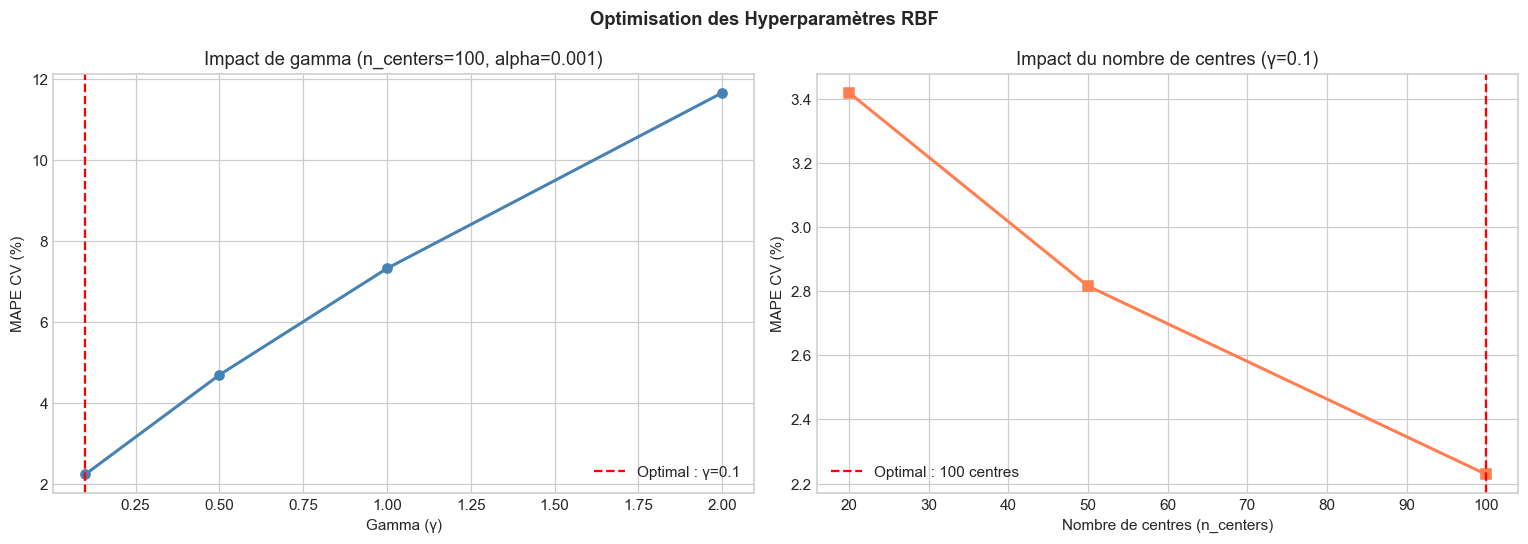

In [5]:
# Visualisation de l'impact de gamma
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle('Optimisation des Hyperparamètres RBF', fontweight='bold')

# Impact de gamma (n_centers fixé au meilleur)
ax1 = axes[0]
n_best = best_config['n_centers']
a_best = best_config['alpha']
gamma_perf = df_cv[(df_cv['n_centers'] == n_best) & (df_cv['alpha'] == a_best)]
ax1.plot(gamma_perf['gamma'], gamma_perf['mape_cv'], 'o-', color='steelblue', linewidth=2)
ax1.axvline(best_config['gamma'], color='red', linestyle='--', label=f"Optimal : γ={best_config['gamma']}")
ax1.set_xlabel('Gamma (γ)')
ax1.set_ylabel('MAPE CV (%)')
ax1.set_title(f'Impact de gamma (n_centers={n_best}, alpha={a_best})')
ax1.legend()

# Impact du nombre de centres
ax2 = axes[1]
g_best = best_config['gamma']
centers_perf = df_cv[(df_cv['gamma'] == g_best) & (df_cv['alpha'] == a_best)]
ax2.plot(centers_perf['n_centers'], centers_perf['mape_cv'], 's-', color='coral', linewidth=2)
ax2.axvline(best_config['n_centers'], color='red', linestyle='--',
             label=f"Optimal : {best_config['n_centers']} centres")
ax2.set_xlabel('Nombre de centres (n_centers)')
ax2.set_ylabel('MAPE CV (%)')
ax2.set_title(f'Impact du nombre de centres (γ={g_best})')
ax2.legend()

plt.tight_layout()
plt.savefig(PROCESSED_PATH / '09_rbf_hyperparam.png', dpi=150, bbox_inches='tight')
plt.show()

## 3. Entraînement du modèle final

In [6]:
t0 = time.time()

rbf_final = RBFNetwork(
    n_centers=best_config['n_centers'],
    gamma=best_config['gamma'],
    alpha=best_config['alpha'],
    random_state=42
)
rbf_final.fit(X_train, y_train)

training_time = time.time() - t0
print(f'Entraînement terminé en {training_time:.1f}s')
print(f'Centres RBF appris : {rbf_final.centers_.shape}')
print(f'Poids de sortie    : {rbf_final.output_layer_.coef_.shape}')

Entraînement terminé en 0.7s
Centres RBF appris : (100, 14)
Poids de sortie    : (100,)


## 4. Visualisation des centres RBF (PCA 2D)

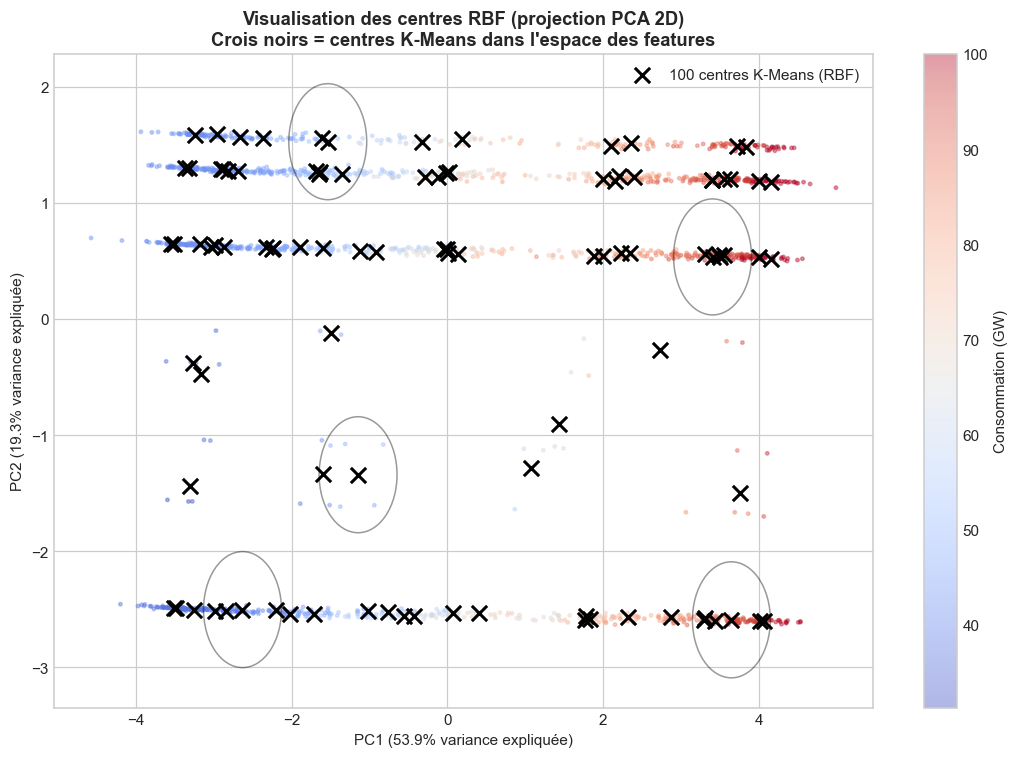

Variance totale expliquée par PC1+PC2 : 73.1%


In [7]:
# Projection en 2D via PCA pour visualiser les centres K-Means
pca = PCA(n_components=2, random_state=42)
X_train_2d = pca.fit_transform(X_train)
centers_2d = pca.transform(rbf_final.centers_)

fig, ax = plt.subplots(figsize=(10, 7))

# Données d'entraînement colorées par la consommation
sc = ax.scatter(X_train_2d[:, 0], X_train_2d[:, 1],
                c=y_train / 1000, cmap='coolwarm', s=5, alpha=0.4)
plt.colorbar(sc, ax=ax, label='Consommation (GW)')

# Centres RBF
ax.scatter(centers_2d[:, 0], centers_2d[:, 1],
           c='black', marker='x', s=100, linewidths=2,
           label=f'{len(centers_2d)} centres K-Means (RBF)', zorder=5)

# Représenter les zones d'influence de quelques centres
for i in range(min(5, len(centers_2d))):
    circle = plt.Circle((centers_2d[i, 0], centers_2d[i, 1]),
                          0.5, fill=False, color='black', linewidth=1, alpha=0.4)
    ax.add_patch(circle)

ax.set_xlabel(f'PC1 ({pca.explained_variance_ratio_[0]*100:.1f}% variance expliquée)')
ax.set_ylabel(f'PC2 ({pca.explained_variance_ratio_[1]*100:.1f}% variance expliquée)')
ax.set_title('Visualisation des centres RBF (projection PCA 2D)\nCrois noirs = centres K-Means dans l\'espace des features', fontweight='bold')
ax.legend(fontsize=10)

plt.tight_layout()
plt.savefig(PROCESSED_PATH / '10_rbf_centres.png', dpi=150, bbox_inches='tight')
plt.show()

print(f'Variance totale expliquée par PC1+PC2 : {sum(pca.explained_variance_ratio_[:2])*100:.1f}%')

## 5. Évaluation


───────────────────────────────────────────────────────
  ÉVALUATION — Réseau RBF
───────────────────────────────────────────────────────
  R² Score          : 0.9935  (cible ≥ 0.90)
  RMSE              : 1,731 MW
  MAPE              : 2.09 %  (cible ≤ 4 %)
  MAE               : 1,314 MW
  Accuracy ±10 %    : 99.8 %
  Accuracy ±5 %     : 92.4 %
  Tps inférence     : 0.1 ms  (cible < 500 ms)
  Échantillons test : 437
───────────────────────────────────────────────────────

  Objectifs EDF :
    Ok  R² ≥ 0.90
    Ok  MAPE ≤ 4 %
    Ok  Accuracy ±10 % ≥ 90 %
    Ok  Inférence < 500 ms


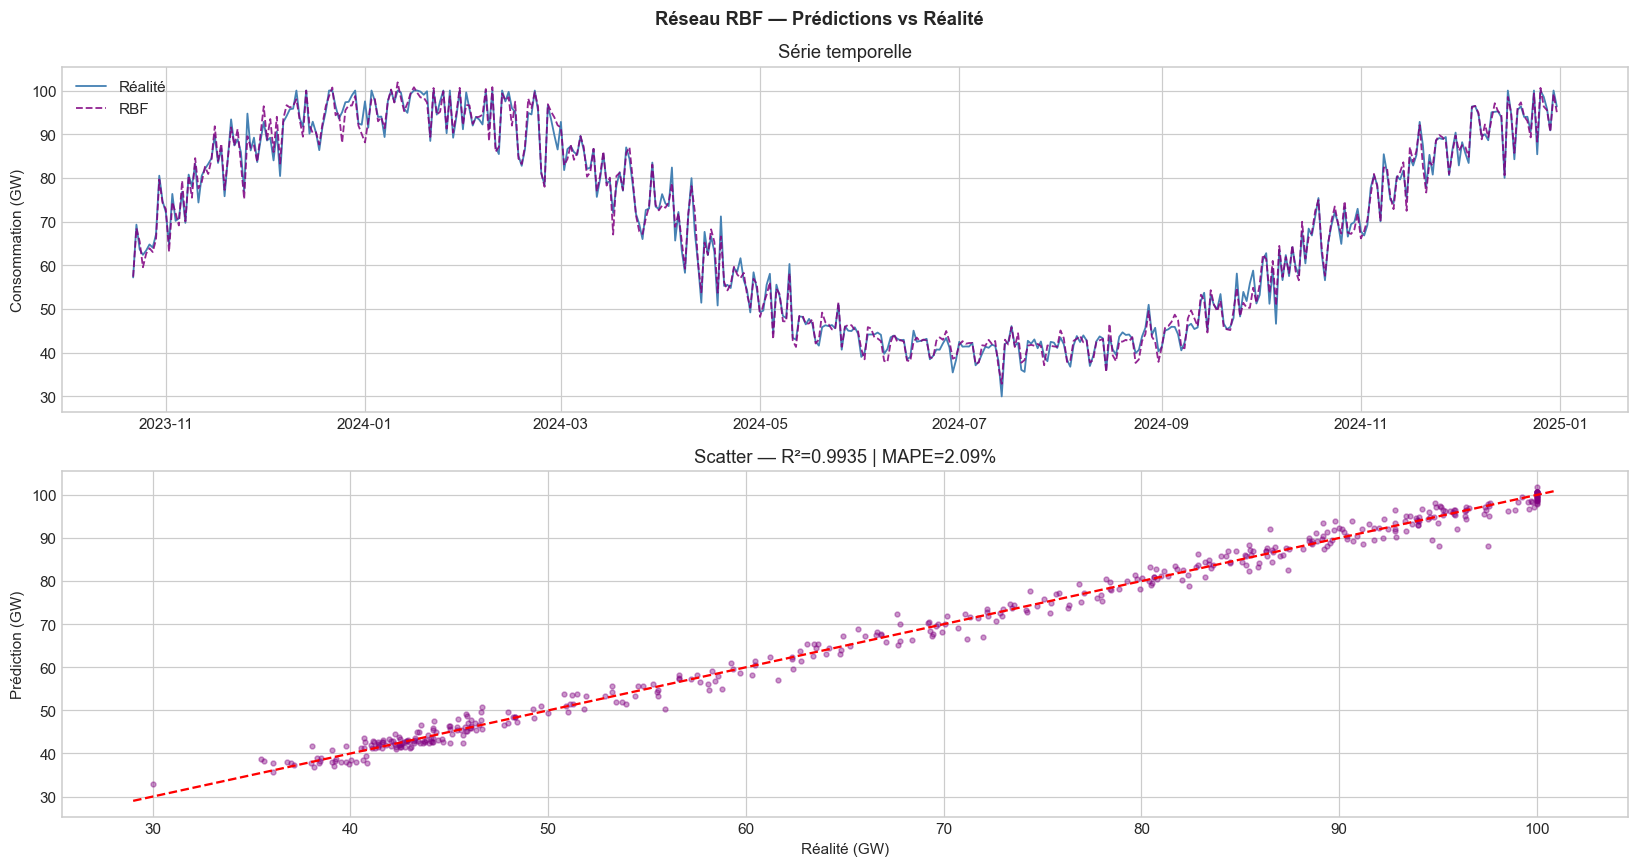

In [8]:
metrics_rbf = evaluate_model(rbf_final, X_test, y_test, model_name='Réseau RBF')

y_pred_rbf = rbf_final.predict(X_test)

# Visualisation prédictions
df_proc = pd.read_parquet(PROCESSED_PATH / 'dataset_processed.parquet')
split_idx = len(y_train)
dates_test = df_proc['date'].values[split_idx:split_idx + len(y_test)]

fig, axes = plt.subplots(2, 1, figsize=(15, 8))
fig.suptitle('Réseau RBF — Prédictions vs Réalité', fontweight='bold')

ax1 = axes[0]
ax1.plot(dates_test, y_test / 1000, label='Réalité', linewidth=1.2, color='steelblue')
ax1.plot(dates_test, y_pred_rbf / 1000, label='RBF', linewidth=1.2,
          color='purple', linestyle='--', alpha=0.85)
ax1.set_ylabel('Consommation (GW)')
ax1.set_title('Série temporelle')
ax1.legend()

ax2 = axes[1]
ax2.scatter(y_test / 1000, y_pred_rbf / 1000, alpha=0.4, s=10, color='purple')
lims = [y_test.min() / 1000 - 1, y_test.max() / 1000 + 1]
ax2.plot(lims, lims, 'r--', linewidth=1.5)
ax2.set_xlabel('Réalité (GW)'); ax2.set_ylabel('Prédiction (GW)')
ax2.set_title(f'Scatter — R²={metrics_rbf["r2"]:.4f} | MAPE={metrics_rbf["mape_pct"]:.2f}%')

plt.tight_layout()
plt.savefig(PROCESSED_PATH / '11_rbf_predictions.png', dpi=150, bbox_inches='tight')
plt.show()

## 6. Sauvegarde

In [9]:
model_path = MODELS_PATH / 'rbf_network_v1.pkl'
rbf_final.save(str(model_path))

metrics_rbf['training_time_s'] = round(training_time, 1)
metrics_rbf['hyperparameters'] = best_config
pd.Series(metrics_rbf).to_json(MODELS_PATH / 'metrics_rbf_network.json')

print(f' Modèle RBF sauvegardé → {model_path}')
print(f'\n RÉSUMÉ Réseau RBF :')
print(f'   R² = {metrics_rbf["r2"]}  |  MAPE = {metrics_rbf["mape_pct"]}%  |  RMSE = {metrics_rbf["rmse_mw"]:,.0f} MW')
print(f'   Temps entraînement : {training_time:.1f}s')

 Modèle RBF sauvegardé → ..\data\models_saved\rbf_network_v1.pkl

 RÉSUMÉ Réseau RBF :
   R² = 0.9935  |  MAPE = 2.09%  |  RMSE = 1,731 MW
   Temps entraînement : 0.7s
